In [1]:
import random
import json
import re
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import importlib

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from sklearn.metrics import confusion_matrix

WORK_DIR = Path.cwd().parent
sys.path.append(str(WORK_DIR))

from src import (
    response_processing as rp,
    video_tools
)
from src.viz_utils import qa_viz
from src.STAR_utils.visualization_tools import qa_visualization as qaviz
from src.STAR_utils.visualization_tools import qa_visualization as videoviz

random.seed(6)
np.random.seed(6)

STAR_VAL_SMALL = WORK_DIR / "data/datasets/STAR/STAR_annotations/STAR_val_small_1000.json"

RAW_VIDEO_DIR = Path(WORK_DIR / 'data/datasets/action-genome/Charades_v1_480/')
SAVE_VIDEO_DIR = Path(WORK_DIR / "experiments/video_dump")

#-------------- 200 sub-set
# SGG_GRAPHS = WORK_DIR / "scripts/data/aggregated_final_sgg_200.jsonl"

# # The file below has been run with a context window of 8_192
# GEMINI_RESPONSES_FPATH = WORK_DIR / "scripts/data/aggregated_final_gu_u3_on_geminiSGG_gemini2.5flash_20250804_21:49:00.jsonl"
# # The file below has been run with a longer context window 8_192
# GEMINI_RESPONSES_FPATH = WORK_DIR / "scripts/data/aggregated_final_gu_u3_200_on_geminiSGG_gemini25flash_20250825_15:48:00.jsonl"
# GEMMA_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:4b_on_gemini_stsg_200_20250804_19:21:00.jsonl"


# -------------- 1000 subset
#SGG_GRAPHS = WORK_DIR / "scripts/data/aggregated_final_sgg_gemini25flash_1000.jsonl"

#GEMMA_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:4b_on_gemini_stsg_1000_20250805_15:48:00.jsonl"
#GEMMA_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:12b_on_gemini_stsg_1000_20250806_17:30:00.jsonl"

#GEMMA_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:4b_on_gemini_stsg_1000_20250825_18:30:00.jsonl"
#GEMMA_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:12b_on_gemini_stsg_1000_20250826_18:30:00.jsonl"

#GEMINI_RESPONSES_FPATH = WORK_DIR / "scripts/data/aggregated_final_gu_u3_1000_on_geminiSGG_gemini25flash_20250805_15:48:00.jsonl"
#GEMINI_RESPONSES_FPATH = WORK_DIR / "scripts/data/aggregated_final_gu_u3_1000_on_geminiSGG_gemini25flash_20250828_17:48:00.jsonl"
GEMINI_RESPONSES_FPATH = WORK_DIR / "scripts/data/aggregated_final_gu_u3_1000_on_geminiSGG_gemini25flash_20250830_14:52:00.jsonl"


# -------------- 1000 subset
# -------------- Longer OutTokens gen SGG
# -------------- Longer OutTokens GU
SGG_GRAPHS = WORK_DIR / "scripts/data/aggregated_final_sgg_gemini2.5flash_1000_OutTokens8192_20250829_22:00:00.jsonl"

#GEMINI_RESPONSES_FPATH = WORK_DIR / "scripts/data/aggregated_final_gu_u3_200_on_geminiSGG_gemini25flash_20250830_14:52:00.jsonl"

# 4B
#GEMMA_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:4b_on_gemini_stsg_1000_20250830_14:52:00.jsonl"
# 12B
GEMMA_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:12b_on_gemini_stsg_1000_20250830_14:52:00.jsonl"

RAW_VIDEO_DIR = Path(WORK_DIR / 'data/datasets/action-genome/Charades_v1_480/')
SAVE_VIDEO_DIR = Path(WORK_DIR / "experiments/video_dump")


prev_analyzed = [
    "Interaction_T1_4054",
    "Interaction_T1_8913",
    "Interaction_T2_3423",
    "Interaction_T1_4115",
    "Interaction_T1_1168",
    "Interaction_T1_309",
    "Interaction_T1_4703",
    "Interaction_T1_2516",
    "Interaction_T1_8967",
    "Interaction_T1_5709",
    "Interaction_T1_2226",
    "Interaction_T1_111",
    "Interaction_T1_8274",
    "Interaction_T1_7254",
    "Interaction_T1_4221",
    #"Interaction_T1_3485",
    #"Interaction_T4_4181",
    #"Interaction_T2_1847",
]

SHOW_VIDEO = False


Comparison between Gemma3:4b and Gemini 2.5 flash on the Graph QA task on the STSG generated by Gemini 2.5 flash

## Load GT

In [2]:
with open(STAR_VAL_SMALL, 'r') as f:
    gt_df = pd.read_json(f)

gt_df = gt_df.rename(columns={'answer': 'text'})
gt_df = gt_df.set_index('question_id')
gt_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1048 entries, Feasibility_T5_102 to Interaction_T4_4181
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   question          1048 non-null   object 
 1   video_id          1048 non-null   object 
 2   start             1048 non-null   float64
 3   end               1048 non-null   float64
 4   text              1048 non-null   object 
 5   question_program  1048 non-null   object 
 6   choices           1048 non-null   object 
 7   situations        1048 non-null   object 
dtypes: float64(2), object(6)
memory usage: 73.7+ KB


## Load predictions

In [3]:
gemma_pred_gg_df = rp.ans_extract(GEMMA_RESPONSES_FPATH, "gemma3", format="ollama")
gemini_pred_gg_df = rp.ans_extract(GEMINI_RESPONSES_FPATH, "gemma3", format="gemini")


/home/lusha/star_code/src/response_processing.py:187: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(
Error executing eval on: {"answer": "The provided Spatio-Temporal Scene Graph does not contain any information about the person holding food. Therefore, it is not possible to answer what happened after the person held the food based on the given data. None of the alternatives can be confirmed or denied in relation to the premise of \holding food.\"}.


Total answers: 1033
Answers following JSON template: 1031
Percentage following JSON template: 99.81%
Answer with a valid alternative: 920
89.23% of the total

Invalid answers: 111
Total answers: 1033
Answers following JSON template: 1033
Percentage following JSON template: 100.00%
Answer with a valid alternative: 902
87.32% of the total

Invalid answers: 131


/home/lusha/star_code/src/response_processing.py:187: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(


## Sanity-check

### Gemini sanity-check

#### Sample question

In [4]:
print(gemini_pred_gg_df.iloc[0]["chat_history"][0]["content"])



Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
<stsg>
Frame 0:
<scene_graph>
person ---- wearing ---- green_t-shirt
person ---- holding ---- open_book
person ---- located_near ---- window
window ---- showing ---- outdoor_building_structure
doorway ---- leading_to ---- dimly_lit_room
room ---- containing ---- ornate_wooden_screen
</scene_graph>

Frame 1:
<scene_graph>
person ---- wearing ---- green_t-shirt
person ---- holding ---- open_book
person ---- raising ---- right_hand
right_hand ---- moving_towards ---- wall
person ---- looking_at ---- wall
</scene_graph>

Frame 2:
<scene_graph>
person ---- wearing ---- green_t-shirt
person ---- holding ---- open_book
right_hand ---- touching ---- wooden_object
wooden_object ---- mounted_on ---- wall
person ---- looking_at ---- wooden_object
</scene_graph>

Frame 3:
<scene_graph>
person ---- wearing ---- green_t-shirt
person ---- holding ---- open

In [5]:
print(gemini_pred_gg_df.iloc[0]["chat_history"][1]["content"])



1. **Question Interpretation:** The question asks what action the person is able to perform in relation to the window, based on the provided Spatio-Temporal Scene Graph.

2. **STSG Analysis:**
    *   **Frame 0:** "person ---- located_near ---- window" and "window ---- showing ---- outdoor_building_structure". This establishes the presence of a window and its state (showing the outside). There is no information about the window's functionality or the person's interaction with it.
    *   **Frames 1-6:** The person interacts with a "wooden_object" on the wall, adjusting it. The window is not mentioned.
    *   **Frame 7:** The person is looking at an "open_book". The window is not mentioned.

    The STSG explicitly states that the "person ---- located_near ---- window" in Frame 0 and that the "window ---- showing ---- outdoor_building_structure". However, it *does not provide any information* about the window's type (e.g., if it's openable), or any interaction between the person and t

In [6]:
print(gemini_pred_gg_df.iloc[0]["chat_history"][2]["content"])



Therefore the final answer is?

Your response must be provided in valid JSON format as follows:
{"answer": "your complete answer here"}

IMPORTANT: Always include both the letter (A, B, C, D, etc.) AND the full text of the answer in your response.
Do not abbreviate or shorten the answer. For example, if the correct answer is "A. the laptop", your response 
should be {"answer": "A. the laptop"}, not {"answer": "laptop"} or {"answer": "A"}.\



In [7]:
print(gemini_pred_gg_df.iloc[0]["chat_history"][3]["content"])



```json
{
"answer": "The provided Spatio-Temporal Scene Graph does not contain any information about the window's functionality or any interaction between the person and the window that would allow for opening, closing, holding, or lying on it. The STSG only states that a 'person ---- located_near ---- window' and 'window ---- showing ---- outdoor_building_structure'. Without any further information in the STSG about the window's attributes or the person's actions related to it, it is impossible to logically infer that the person is able to perform any of the actions listed in the alternatives. Therefore, based strictly on the provided STSG, none of the alternatives can be supported as a correct answer."
}
```


#### Unanswered questions

In [8]:
for _, row in gemini_pred_gg_df[~gemini_pred_gg_df["contains_answer"]].iterrows():
    print(row["chat_history"][-1]["content"])



```json
{
"answer": "The provided Spatio-Temporal Scene Graph does not contain any information about the window's functionality or any interaction between the person and the window that would allow for opening, closing, holding, or lying on it. The STSG only states that a 'person ---- located_near ---- window' and 'window ---- showing ---- outdoor_building_structure'. Without any further information in the STSG about the window's attributes or the person's actions related to it, it is impossible to logically infer that the person is able to perform any of the actions listed in the alternatives. Therefore, based strictly on the provided STSG, none of the alternatives can be supported as a correct answer."
}
```

{"answer": "Based on the provided Spatio-Temporal Scene Graph, the 'person' is consistently described as 'seated_in' a 'chair' and 'in' the 'background' from Frame 0 to Frame 10. There are no actions or changes in state attributed to the 'person' throughout the entire sequence.

### Gemma sanity check

#### Sample question

In [9]:
print(gemma_pred_gg_df.iloc[0]["chat_history"][0]["content"])


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
<stsg>
Frame 0:
<scene_graph>
person ---- wearing ---- green_t-shirt
person ---- holding ---- open_book
person ---- located_near ---- window
window ---- showing ---- outdoor_building_structure
doorway ---- leading_to ---- dimly_lit_room
room ---- containing ---- ornate_wooden_screen
</scene_graph>

Frame 1:
<scene_graph>
person ---- wearing ---- green_t-shirt
person ---- holding ---- open_book
person ---- raising ---- right_hand
right_hand ---- moving_towards ---- wall
person ---- looking_at ---- wall
</scene_graph>

Frame 2:
<scene_graph>
person ---- wearing ---- green_t-shirt
person ---- holding ---- open_book
right_hand ---- touching ---- wooden_object
wooden_object ---- mounted_on ---- wall
person ---- looking_at ---- wooden_object
</scene_graph>

Frame 3:
<scene_graph>
person ---- wearing ---- green_t-shirt
person ---- holding ---- open_

In [10]:
print(gemma_pred_gg_df.iloc[0]["chat_history"][1]["content"])


Okay, let's break down this question and the STSG to determine the best answer.

**1. Question Interpretation:**

The question "What else is the person able to do with the window?" is asking us to infer potential actions the person could take with the window, based on the information provided in the STSG. The question implies that the person is already interacting with the scene in some way, and we need to find a plausible additional action related to the window.

**2. STSG Analysis:**

The STSG describes a scene involving a person, a window, and other objects. Let's focus on the window-related information:

*   **Frame 0:** "window ---- showing ---- outdoor_building_structure" - This establishes the window's function: it provides a view of something outside.
*   No other frames explicitly mention the window or any interaction with it.

**3. Alternative Evaluation:**

Let's evaluate each alternative:

*   **A. Lie on the window:** The STSG doesn't suggest the window is large enough or 

In [11]:
print(gemma_pred_gg_df.iloc[0]["chat_history"][2]["content"])


Therefore the final answer is?

Your response must be provided in valid JSON format as follows:
{"answer": "your complete answer here"}

IMPORTANT: Always include both the letter (A, B, C, D, etc.) AND the full text of the answer in your response.
Do not abbreviate or shorten the answer. For example, if the correct answer is "A. the laptop", your response 
should be {"answer": "A. the laptop"}, not {"answer": "laptop"} or {"answer": "A"}.\


In [12]:
print(gemma_pred_gg_df.iloc[0]["chat_history"][3]["content"])


```json
{"answer": "D. Open the window."}
```


#### Unanswered questions

In [13]:
for _, row in gemma_pred_gg_df[~gemma_pred_gg_df['contains_answer']].iterrows():
    print(row["chat_history"][-1]["content"])


```json
{"answer": "None of the alternatives are supported by the STSG. Therefore, the most logical answer is to assume they will continue their current state, which is remaining seated in the chair."}
```
```json
{"answer": "The question is flawed as none of the provided alternatives (A. The door, B. The book, C. The laptop, D. The closet/cabinet) are explicitly mentioned or implied in the provided Spatio-Temporal Scene Graph. Therefore, a definitive answer cannot be determined from the given information."}
```
```json
{"answer": "The question is flawed as the alternatives do not include the doorknob, which the person was holding. However, if forced to choose from the provided alternatives, none of them are directly supported by the STSG. Therefore, I cannot select a valid answer from the given options."}
```
{"answer": "The question is unanswerable based on the provided STSG, as it does not describe the person putting down any object before interacting with the blue bucket."}
```json

## Evals

In [14]:
gemma_pred_gg_df.rename(columns={'answer': 'pred_text'}, inplace=True)
gemma_eval_df = gt_df.join(
    gemma_pred_gg_df[gemma_pred_gg_df['contains_answer']], 
    how='inner' # we account also for samples without answers
)
rp.print_acc(gemma_eval_df, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          272        64.34%  
Sequence             250        67.20%  
Prediction           202        61.39%  
Feasibility          196        50.00%  

Average              920        61.41%  


/home/lusha/star_code/src/response_processing.py:450: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.text(


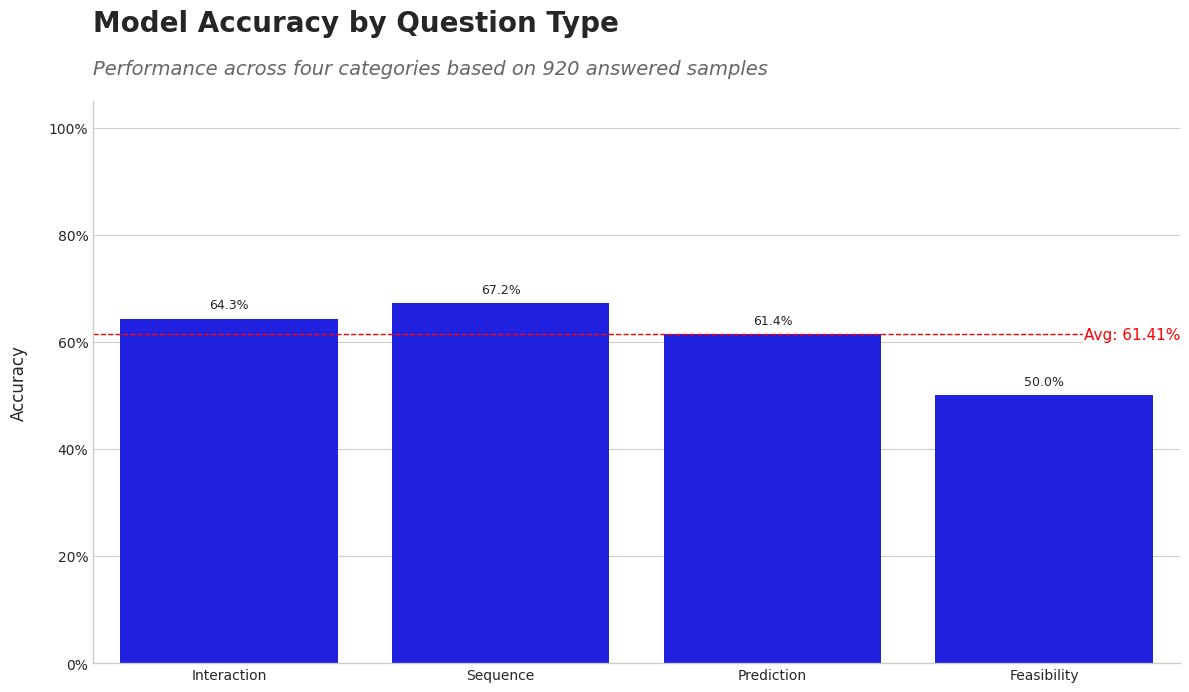

In [15]:
rp.plot_acc(gemma_eval_df, lambda x: rp.accuracy(x, on_what='text'))


In [16]:
rp.print_ans_perc(gemma_eval_df, gt_df)


Question type       Total      Answered 

Interaction          298        91.28%  
Sequence             291        85.91%  
Prediction           239        84.52%  
Feasibility          220        89.09%  
Overall             1048        87.79%  


/home/lusha/star_code/src/response_processing.py:528: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.text(


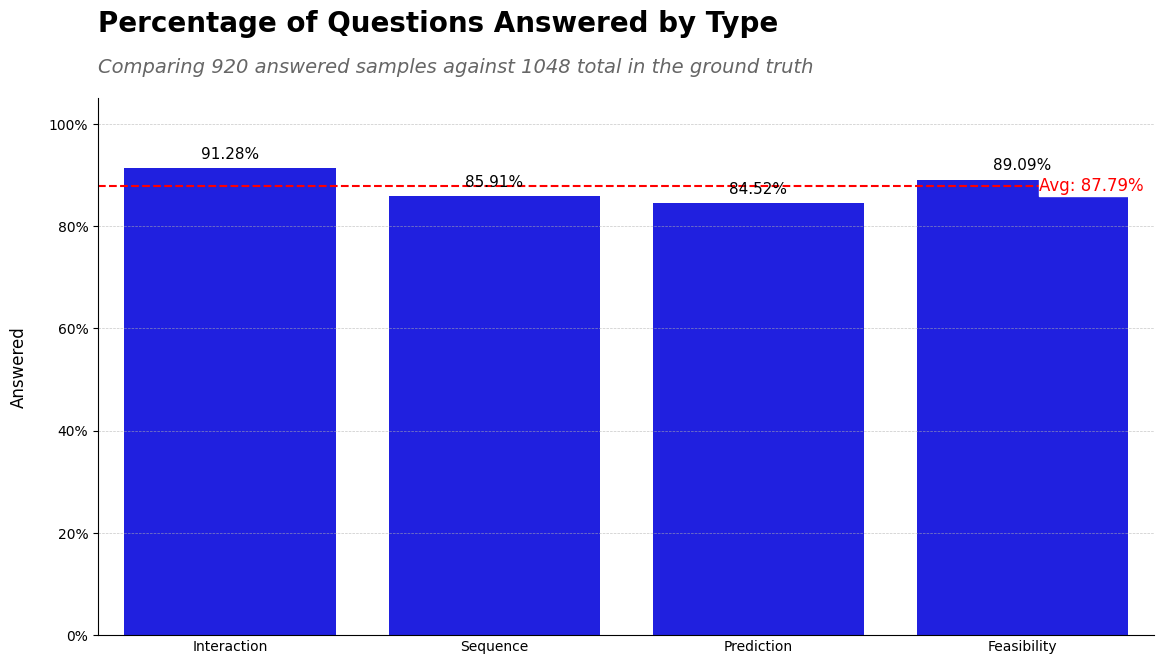

In [17]:
rp.plot_ans_perc(gemma_eval_df, gt_df)


In [18]:
gemini_pred_gg_df.rename(columns={'answer': 'pred_text'}, inplace=True)
gemini_eval_df = gt_df.join(
    gemini_pred_gg_df[gemini_pred_gg_df['contains_answer']], 
    how='inner' # we account also for samples without answers
)
rp.print_acc(gemini_eval_df, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          266        74.44%  
Sequence             246        74.80%  
Prediction           201        62.19%  
Feasibility          189        50.26%  

Average              902        66.74%  


/home/lusha/star_code/src/response_processing.py:450: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.text(


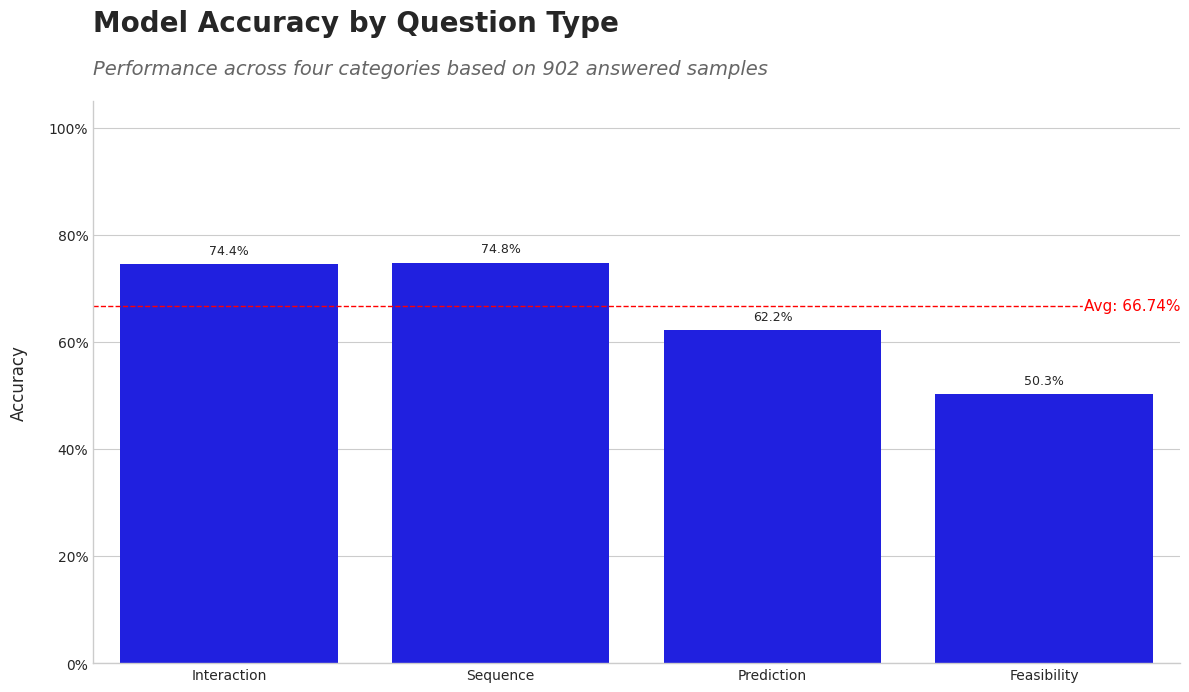

In [19]:
rp.plot_acc(gemini_eval_df, lambda x: rp.accuracy(x, on_what='text'))


In [20]:
rp.print_ans_perc(gemini_eval_df, gt_df)


Question type       Total      Answered 

Interaction          298        89.26%  
Sequence             291        84.54%  
Prediction           239        84.10%  
Feasibility          220        85.91%  
Overall             1048        86.07%  


/home/lusha/star_code/src/response_processing.py:528: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.text(


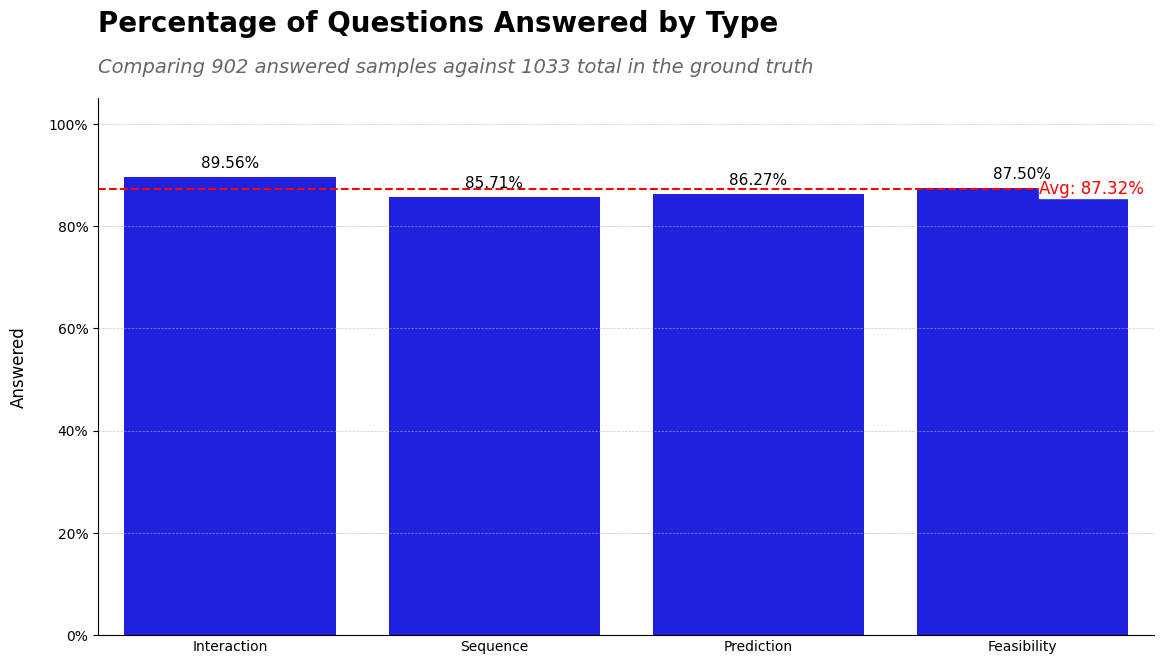

In [21]:
rp.plot_ans_perc(gemini_eval_df, gemini_pred_gg_df)


In [22]:
eval_df_all = gt_df.join(
    gemma_pred_gg_df[gemma_pred_gg_df['contains_answer']].rename(columns={'pred_text': 'pred_text1'})[['pred_text1']],
    how='inner'
).join(
    gemini_pred_gg_df[gemini_pred_gg_df['contains_answer']].rename(columns={'pred_text': 'pred_text2'})[['pred_text2']],
    how='inner'
)

eval_df_all['text'] = eval_df_all['text'].str.lower()
eval_df_all['pred_text1'] = eval_df_all['pred_text1'].str.lower()
eval_df_all['pred_text2'] = eval_df_all['pred_text2'].str.lower()
eval_df_all[['question', 'text', 'pred_text1', 'pred_text2']]


,question,text,pred_text1,pred_text2
Prediction_T2_450,What will the person do next with the clothes?,take.,take.,put down.
Sequence_T5_4571,What did the person do to the clothes after si...,put down.,tidied up.,put down.
Prediction_T1_499,What will the person do next?,put down the shoe.,put down the bag.,put down the bag.
Interaction_T2_6234,What did the person do with the table?,sat at.,put down.,sat at.
Interaction_T3_5587,What did the person do while they were holding...,put down the bag.,put down the bag.,put down the bag.
...,...,...,...,...
Interaction_T1_8913,Which object was taken by the person?,the paper/notebook.,the paper/notebook.,the paper/notebook.
Interaction_T1_8967,Which object was taken by the person?,the dish.,the dish.,the food.
Interaction_T2_1847,What did the person do with the paper/notebook?,took.,took.,put down.
Interaction_T2_3423,What did the person do with the bed?,lied on.,sat on.,sat on.


In [23]:
print(f"Questions answered by both models: \n - {eval_df_all.shape[0]}")


Questions answered by both models: 
 - 832


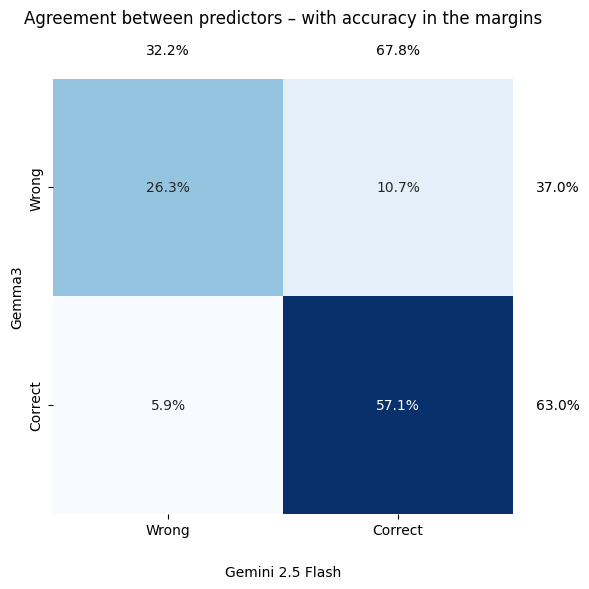

(832, 10)


In [24]:
display_eval = eval_df_all
pred_vqa_correct = (display_eval['text'] == display_eval['pred_text1']).astype(int).values
pred_gg_correct  = (display_eval['text'] == display_eval['pred_text2']).astype(int).values
labels = ['Wrong', 'Correct']

# confusion matrix (normalized over all)
cm = confusion_matrix(pred_vqa_correct, pred_gg_correct, normalize='all')

# compute marginal sums and convert to % of total
row_totals = cm.sum(axis=1)
col_totals = cm.sum(axis=0)
total = cm.sum()
row_pct = row_totals / total
col_pct = col_totals / total

fig, ax = plt.subplots(figsize=(6, 6))  
sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar=False, ax=ax)

# annotate row marginals at the right of each row
for i, p in enumerate(row_pct):
    ax.text(len(labels) + 0.1,  i + 0.5, f'{p:.1%}', 
            va='center', ha='left', fontsize=10)

# annotate column marginals just above each column
for j, p in enumerate(col_pct):
    ax.text(j + 0.5, -0.1, f'{p:.1%}', 
            ha='center', va='bottom', fontsize=10)

# move x-axis labels (and xlabel) to the top
ax.set_xlabel('Gemini 2.5 Flash', labelpad=20)
ax.set_ylabel('Gemma3')
ax.set_title('Agreement between predictors – with accuracy in the margins', pad=40)

# make xtick labels horizontal
ax.set_xticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()
print(eval_df_all.shape)


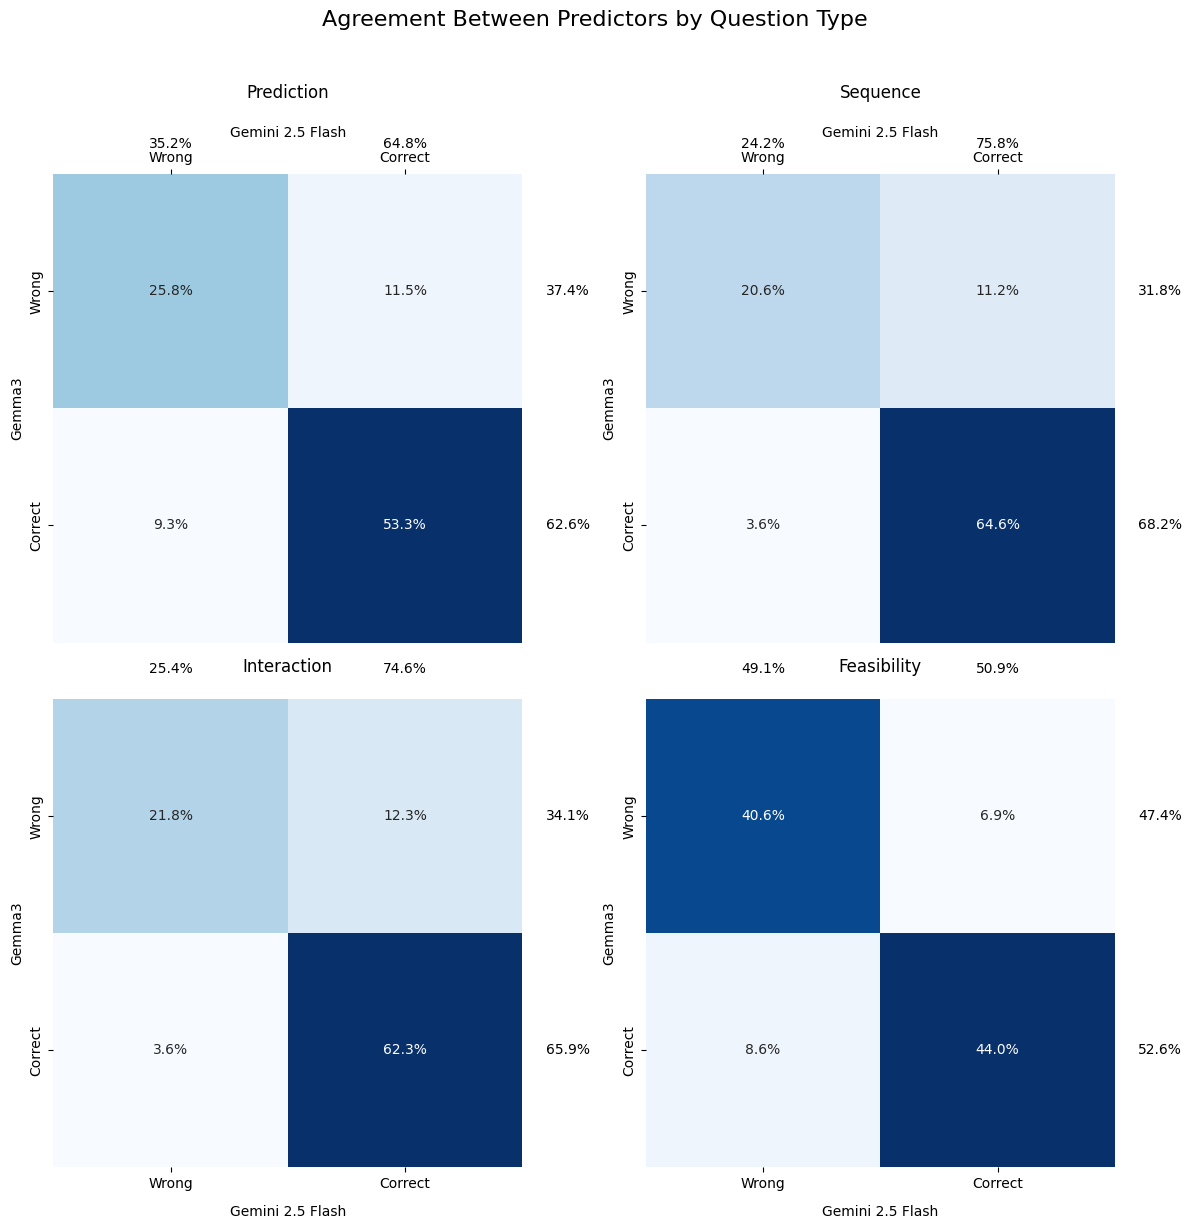

In [25]:
# Create a copy of the DataFrame for visualization
viz_df = eval_df_all.copy()

# Extract question type from the index
viz_df['question_type'] = viz_df.index.str.split('_').str[0]

# Get unique question types
question_types = viz_df['question_type'].unique()

# Set up the plot grid
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle('Agreement Between Predictors by Question Type', y=1.02, fontsize=16)

# Flatten axes for easy iteration
axes = axes.flatten()

for i, qtype in enumerate(question_types):
    # Filter data for this question type
    subset = viz_df[viz_df['question_type'] == qtype]
    
    # Calculate correctness
    pred_vqa_correct = (subset['text'] == subset['pred_text1']).astype(int).values
    pred_gg_correct = (subset['text'] == subset['pred_text2']).astype(int).values
    
    # Confusion matrix (normalized over all)
    cm = confusion_matrix(pred_vqa_correct, pred_gg_correct, normalize='all')
    
    # Compute marginal sums
    row_totals = cm.sum(axis=1)
    col_totals = cm.sum(axis=0)
    total = cm.sum()
    row_pct = row_totals / total
    col_pct = col_totals / total
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                cbar=False, ax=axes[i])
    
    # Annotate row marginals
    for j, p in enumerate(row_pct):
        axes[i].text(len(labels) + 0.1, j + 0.5, f'{p:.1%}', 
                    va='center', ha='left', fontsize=10)
    
    # Annotate column marginals
    for k, p in enumerate(col_pct):
        axes[i].text(k + 0.5, -0.1, f'{p:.1%}', 
                    ha='center', va='bottom', fontsize=10)
    
    # Customize subplot
    axes[i].set_title(qtype, pad=20)
    axes[i].set_xlabel('Gemini 2.5 Flash', labelpad=10)
    axes[i].set_ylabel('Gemma3')
    axes[i].set_xticklabels(labels, rotation=0)
    
    # Move x-axis to top for all but bottom row
    if i < 2:  # Top row
        axes[i].xaxis.set_ticks_position('top')
        axes[i].xaxis.set_label_position('top')

plt.tight_layout()
plt.show()


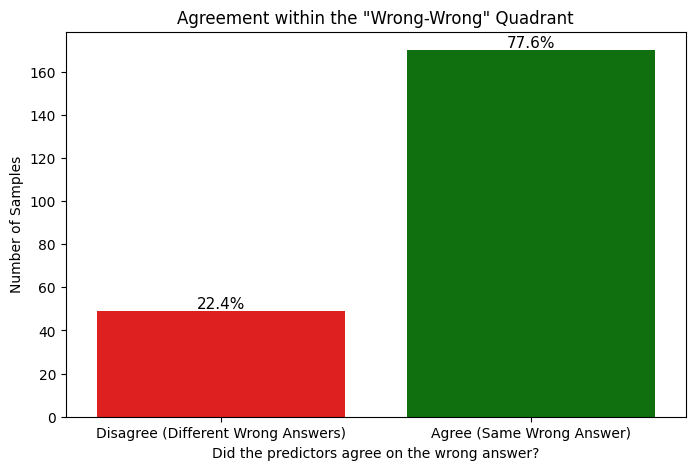

In [26]:
wrong_wrong_df = eval_df_all[
    (eval_df_all['text'] != eval_df_all['pred_text1']) &
    (eval_df_all['text'] != eval_df_all['pred_text2'])
].copy()

wrong_wrong_df['agreement_on_wrong'] = (
    wrong_wrong_df['pred_text1'] == wrong_wrong_df['pred_text2']
)

# Visualize the result
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=wrong_wrong_df,
    x='agreement_on_wrong',
    hue='agreement_on_wrong',
    palette=['Red', 'Green'],
    legend=False
)

plt.title('Agreement within the "Wrong-Wrong" Quadrant')
plt.ylabel('Number of Samples')
plt.xlabel('Did the predictors agree on the wrong answer?')
ax.set_xticks([0, 1]) 
ax.set_xticklabels(['Disagree (Different Wrong Answers)', 'Agree (Same Wrong Answer)'])

# Add percentage annotations
total = len(wrong_wrong_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=11)

plt.show()


/tmp/ipykernel_353198/1012052540.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


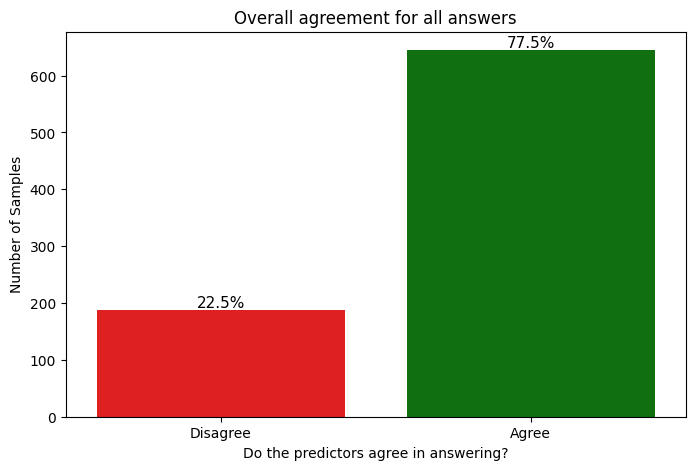

In [27]:
agreement_df = pd.DataFrame((eval_df_all['pred_text1'] == eval_df_all['pred_text2']), columns=['agreement'])

# Visualize the result
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=agreement_df,
    x='agreement',
    palette=['Red', 'Green']
)

plt.title('Overall agreement for all answers')
plt.ylabel('Number of Samples')
plt.xlabel('Do the predictors agree in answering?')
ax.set_xticks([0, 1]) 
ax.set_xticklabels(['Disagree', 'Agree'])

# Add percentage annotations
total = len(agreement_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=11)

plt.show()


/tmp/ipykernel_353198/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_353198/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_353198/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_353198/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


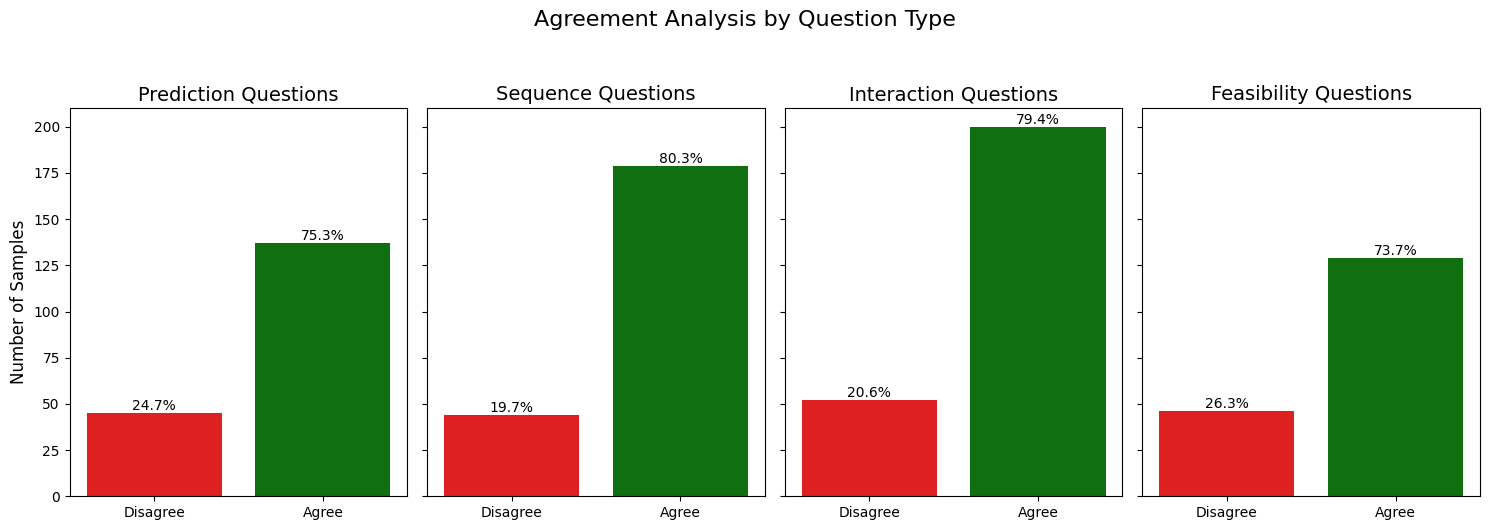

In [28]:
# Create a copy of the DataFrame for visualization
viz_df = eval_df_all.copy()

# Extract question type from the index
viz_df['question_type'] = viz_df.index.str.split('_').str[0]

# Create agreement column in the copy
viz_df['agreement'] = viz_df['pred_text1'] == viz_df['pred_text2']

# Get unique question types
question_types = viz_df['question_type'].unique()
n_types = len(question_types)

# Create subplots
fig, axes = plt.subplots(1, n_types, figsize=(15, 5), sharey=True)
fig.suptitle('Agreement Analysis by Question Type', fontsize=16, y=1.05)

for i, qtype in enumerate(question_types):
    # Filter data for this question type
    subset = viz_df[viz_df['question_type'] == qtype]
    
    # Create countplot
    ax = sns.countplot(
        data=subset,
        x='agreement',
        palette=['Red', 'Green'],
        ax=axes[i]
    )
    
    # Set title and labels
    ax.set_title(f'{qtype} Questions', fontsize=14)
    ax.set_xlabel('')
    if i == 0:
        ax.set_ylabel('Number of Samples', fontsize=12)
    
    # Set x-ticks
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Disagree', 'Agree'])
    
    # Add percentage annotations
    total = len(subset)
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


## Inspection - 1
Check why Gemini doesn't answer some on the questions

In [29]:
gemma_pred_gg_df = rp.ans_extract(GEMMA_RESPONSES_FPATH, "gemma3", format="ollama")
gemini_pred_gg_df = rp.ans_extract(GEMINI_RESPONSES_FPATH, "gemma3", format="gemini")


/home/lusha/star_code/src/response_processing.py:187: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(
Error executing eval on: {"answer": "The provided Spatio-Temporal Scene Graph does not contain any information about the person holding food. Therefore, it is not possible to answer what happened after the person held the food based on the given data. None of the alternatives can be confirmed or denied in relation to the premise of \holding food.\"}.


Total answers: 1033
Answers following JSON template: 1031
Percentage following JSON template: 99.81%
Answer with a valid alternative: 920
89.23% of the total

Invalid answers: 111
Total answers: 1033
Answers following JSON template: 1033
Percentage following JSON template: 100.00%
Answer with a valid alternative: 902
87.32% of the total

Invalid answers: 131


/home/lusha/star_code/src/response_processing.py:187: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(


In [30]:
gemini_unanswered = gemini_pred_gg_df[~gemini_pred_gg_df['contains_answer']]
gemini_unanswered_index = gemini_unanswered.index


## Sample

In [165]:
SHOW_VIDEO = False
idx = gemini_unanswered_index[9]
idx = "Sequence_T4_1402"


### Text inspection

##### Gemini

In [166]:
qa_viz.compact_print_qa(idx, gt_df.rename(columns={'text': 'answer'}), [gemini_pred_gg_df.rename(columns={'answer': 'pred_text'})])



┌─ Sample: Sequence_T4_1402 ────────────────────────────────────────────────────────────────
│
│ Question:
│    What happened before the person held the medicine?
│ Alternatives:
│    0. Took the dish.
│    1. Opened the box.
│    2. Threw the box.
│    3. Washed the window.
│
│ Ground Truth:
│    Opened the box.
│
│
│ Model Predictions - Prediction 1:
│    Prediction:
│        Took the dish. [WRONG]
│    Reasoning:
│        
│        1. **Question Interpretation:** The question asks to identify the action performed by the person immediately before they started holding what is later identified as a "clear_bottle" (which is likely the medicine).
│        
│        2. **STSG Analysis:**
│            *   **Frame 0-3:** The man is holding a spoon and an orange_brown_container, scooping from the container. This looks like he's eating.
│            *   **Frame 4:** The man is bringing the spoon to his mouth and ingesting from it. He is still holding the orange_brown_container. This confirms

In [167]:
print(gemini_pred_gg_df.loc[idx]['chat_history'][0]['content'])



Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
<stsg>
Frame 0-3:
<scene_graph>
man ---- standing_in_front_of ---- surface
man ---- wearing ---- polo_shirt
man ---- holding_in_left_hand ---- spoon
man ---- holding_in_right_hand ---- orange_brown_container
spoon ---- scooping_from ---- orange_brown_container
electrical_outlets ---- on_left_of ---- man
door ---- on_right_of ---- man
door ---- has ---- gridded_pattern
various_items ---- on_top_of ---- surface
</scene_graph>

Frame 4:
<scene_graph>
man ---- standing_in_front_of ---- surface
man ---- wearing ---- polo_shirt
man ---- bringing ---- spoon_to_mouth
man ---- ingesting_from ---- spoon
man ---- holding_in_right_hand ---- orange_brown_container
spoon ---- contains ---- contents
electrical_outlets ---- on_left_of ---- man
door ---- on_right_of ---- man
door ---- has ---- gridded_pattern
various_items ---- on_top_of ---- surface
</scene

In [168]:
print(gemini_pred_gg_df.loc[idx]['chat_history'][1]['content'])



1. **Question Interpretation:** The question asks to identify the action performed by the person immediately before they started holding what is later identified as a "clear_bottle" (which is likely the medicine).

2. **STSG Analysis:**
    *   **Frame 0-3:** The man is holding a spoon and an orange_brown_container, scooping from the container. This looks like he's eating.
    *   **Frame 4:** The man is bringing the spoon to his mouth and ingesting from it. He is still holding the orange_brown_container. This confirms he is eating.
    *   **Frame 5:** The man is looking at a white_and_blue_carton and holding the orange_brown_container. A clear_bottle is near the carton.
    *   **Frame 6-11:** The man is manipulating and opening/closing a clear_bottle. This is the first time he is explicitly holding/manipulating the "clear_bottle".
    *   **Frame 12-16:** The man is holding a dark_tool and interacting with the clear_bottle_cap, further confirming his interaction with the bottle.

3

In [169]:
print(gemini_pred_gg_df.loc[idx]['chat_history'][3]['content'])



```json
{"answer": "A. Took the dish."}
```


#### Gemma

In [170]:
idx


'Sequence_T4_1402'

In [171]:
qa_viz.compact_print_qa(idx, gt_df.rename(columns={'text': 'answer'}), [gemma_pred_gg_df.rename(columns={'answer': 'pred_text'})])



┌─ Sample: Sequence_T4_1402 ────────────────────────────────────────────────────────────────
│
│ Question:
│    What happened before the person held the medicine?
│ Alternatives:
│    0. Took the dish.
│    1. Opened the box.
│    2. Threw the box.
│    3. Washed the window.
│
│ Ground Truth:
│    Opened the box.
│
│
│ Model Predictions - Prediction 1:
│    Prediction:
│        Opened the box. [CORRECT]
│    Reasoning:
│        Okay, let's break down this question and the STSG to determine what happened before the person held the medicine.
│        
│        **1. Question Interpretation:**
│        
│        The question asks us to identify an action that occurred *immediately* before the person held the medicine. The STSG doesn't explicitly mention "medicine," but we need to infer what "medicine" refers to based on the context. Given the actions of opening a carton and using a screwdriver, it's reasonable to assume "medicine" refers to the contents of the white and blue carton.
│    

In [172]:
print(gemma_pred_gg_df.loc[idx]['chat_history'][0]['content'])


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
<stsg>
Frame 0:
<scene_graph>
man ---- wearing ---- polo_shirt
man ---- looking_at ---- hands
man ---- holding_in_left_hand ---- spoon
man ---- holding_in_right_hand ---- cylindrical_container
cylindrical_container ---- in_front_of ---- man
bottles_and_containers ---- on_top_of ---- surface
surface ---- to_the_left_of ---- man
</scene_graph>

Frame 1-3:
<scene_graph>
man ---- wearing ---- polo_shirt
man ---- looking_at ---- hands
man ---- holding_in_left_hand ---- spoon
man ---- holding_in_right_hand ---- cylindrical_container
man ---- manipulating ---- contents_in_spoon
man ---- manipulating ---- cylindrical_container
cylindrical_container ---- in_front_of ---- man
bottles_and_containers ---- on_top_of ---- surface
surface ---- to_the_left_of ---- man
</scene_graph>

Frame 4:
<scene_graph>
man ---- wearing ---- polo_shirt
man ---- bringing -

In [173]:
print(gemma_pred_gg_df.loc[idx]['chat_history'][1]['content'])


Okay, let's break down this question and the STSG to determine what happened before the person held the medicine.

**1. Question Interpretation:**

The question asks us to identify an action that occurred *immediately* before the person held the medicine. The STSG doesn't explicitly mention "medicine," but we need to infer what "medicine" refers to based on the context. Given the actions of opening a carton and using a screwdriver, it's reasonable to assume "medicine" refers to the contents of the white and blue carton.

**2. STSG Analysis:**

We need to find the frame *immediately* preceding the frame where the person is holding the medicine (the carton). Let's trace the relevant events:

*   **Frames 1-3:** The person is manipulating the contents of the spoon and the cylindrical container.
*   **Frame 4:** The person brings the spoon to their mouth and consumes something.
*   **Frame 5:** The person lowers their left hand and looks at items on the surface.
*   **Frame 6:** The person

In [174]:
print(gemma_pred_gg_df.loc[idx]['chat_history'][3]['content'])


```json
{"answer": "B. Opened the box."}
```


### Visual Inspection

#### Inspect frames

In [175]:
import math

frames_per_row = 6

if SHOW_VIDEO:
    video_path = RAW_VIDEO_DIR / f"{gt_df.loc[idx]['video_id']}.mp4"
    start = gt_df.loc[idx]['start']
    end = gt_df.loc[idx]['end']
    # values used in the experiments
    fps = 1
    max_frames = 64

    frame_dir, frame_paths = video_tools.extract_frames(
        video_path,
        fps=fps,
        max_frames=max_frames,
        start_time=start,
        end_time=end,
    )
    
    frames_per_row = min(frames_per_row, len(frame_paths))
    rows = math.ceil(len(frame_paths) / frames_per_row)
    
    images = frame_paths
    fig, axes = plt.subplots(rows, frames_per_row, figsize=(18, 4))
    axes = axes.flatten()
    
    for i, img_path in enumerate(images):
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"{i+1}")
        axes[i].axis('off')
    
    # Turn off the axes for any remaining subplots
    for i in range(len(images), len(axes)):
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()


#### Inspect the video

In [176]:
if SHOW_VIDEO:
    videoviz.Vis_Video(
        {"question_id": idx, **gt_df.loc[idx].to_dict()},
        RAW_VIDEO_DIR,
        SAVE_VIDEO_DIR)


# Increasing the output tokens limit

In [43]:
GEMINI_RESPONSES_ORIGINAL = WORK_DIR / "scripts/data/aggregated_final_gu_u3_on_geminiSGG_gemini2.5flash_20250804_21:49:00.jsonl"
# The file below has been run with a longer context window 8_192
GEMINI_RESPONSES_LONGER_CONTEXT= WORK_DIR / "scripts/data/aggregated_final_gu_u3_200_on_geminiSGG_gemini25flash_20250825_15:48:00.jsonl"


In [44]:
gemini_original_df = rp.ans_extract(GEMINI_RESPONSES_ORIGINAL, "gemma3", format="gemini")
gemini_longer_df = rp.ans_extract(GEMINI_RESPONSES_LONGER_CONTEXT, "gemma3", format="gemini")


Error executing eval on: {  "answer": "Based on the provided Spatio-Temporal Scene Graph, the person does not close any object before holding a 'small_dark_object' (Frame 4) or a 'mobile_phone' (Frame 5). The 'upper_cabinet' door, which the person interacts with, is explicitly stated to be 'open' from Frame 3 until the end of the sequence (Frame 8). Therefore, none of the alternatives are supported by the given STSG as an action that occurred. Since I must choose one of the alternatives, and acknowledging the lack of evidence for any closing action, it is impossible to definitively select a correct answer from the given options based on the provided STSG. If forced to choose the "closest" related object, it would be the cabinet/door, but the action of closing is absent." }.
Error executing eval on: {  "answer": "The provided Spatio-Temporal Scene Graph does not contain any information indicating that the man was "touching the book" at any point. While the man is consistently "sitting_o

Total answers: 199
Answers following JSON template: 199
Percentage following JSON template: 100.00%
Answer with a valid alternative: 150
75.38% of the total

Invalid answers: 49
Total answers: 199
Answers following JSON template: 198
Percentage following JSON template: 99.50%
Answer with a valid alternative: 174
87.88% of the total

Invalid answers: 24


/home/lusha/star_code/src/response_processing.py:187: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(


In [45]:
gemini_original_df.rename(columns={'answer': 'pred_text'}, inplace=True)
gemini_original_eval_df = gt_df.join(
    gemini_original_df, 
    how='inner' # we account also for samples without answers
)
rp.print_acc(
    gemini_original_eval_df[gemini_original_eval_df['contains_answer']],
    lambda x: rp.accuracy(x, on_what='text')
)


Question type       Total      Accuracy 

Interaction          36         72.22%  
Sequence             37         83.78%  
Prediction           39         64.10%  
Feasibility          38         42.11%  

Average              150        65.33%  


In [46]:
gemini_longer_df.rename(columns={'answer': 'pred_text'}, inplace=True)
gemini_longer_eval_df = gt_df.join(
    gemini_longer_df, 
    how='inner' # we account also for samples without answers
)

rp.print_acc(gemini_longer_eval_df[gemini_longer_eval_df['contains_answer']], lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          43         65.12%  
Sequence             44         84.09%  
Prediction           44         63.64%  
Feasibility          43         48.84%  

Average              174        65.52%  


As we can see from the statistics, the percentage of answered question increases, while the accuracy values is not affected. Meaning that increasing the context window allowed to answer more question with the same accuracy, or in another words, some of the before truncated answer were actually correct answers and increasing the context window allowed to catch this error, increasing the overall accuracy score considering  all the answers, as shown by the graph below:

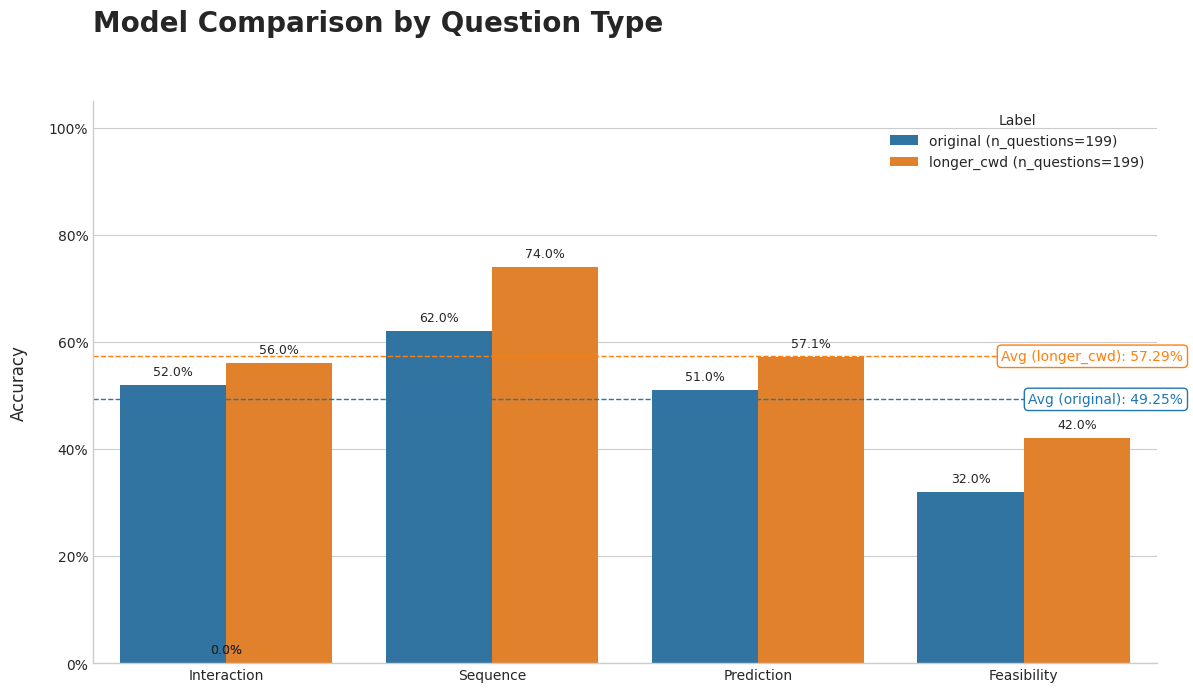

In [47]:
rp.plot_acc(
    [gemini_original_eval_df, gemini_longer_eval_df],
    labels=['original', 'longer_cwd'], 
    acc_fn=lambda x: rp.accuracy(x, on_what='text'), )


In the above graph we compute the exact match accuracy considering also the missing answer, i.e. those for which we do not have a answer compliant with the output format.

In [48]:
NO_ANS = [
    "Prediction_T4_570",
    "Interaction_T4_4146",
    "Prediction_T1_2244",
    "Feasibility_T5_1244",
    "Interaction_T1_4703",
]

TRUNCATED_ANS = [
    "Sequence_T2_1526",
    "Feasibility_T5_1670",
    "Interaction_T1_5145",
    "Sequence_T3_191",
    "Prediction_T1_2030",
]


In [49]:
rp.print_acc(gemini_original_eval_df.loc[TRUNCATED_ANS], lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction           1         0.00%   
Sequence              2         0.00%   
Prediction            1         0.00%   
Feasibility           1         0.00%   

Average               5         0.00%   


In [50]:
gemini_longer_eval_df.loc[TRUNCATED_ANS]['contains_answer'].sum()


3

From the previous truncated answer we recovered 3 out of 5 answers, i.e. answer that before were not conforming in choosing one of the alternatives.

In [51]:
rp.print_acc(gemini_longer_eval_df.loc[TRUNCATED_ANS][gemini_longer_eval_df.loc[TRUNCATED_ANS]['contains_answer']], lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction           1         0.00%   
Sequence              1        100.00%  
Prediction            0          nan%   
Feasibility           1        100.00%  

Average               3         66.67%  


/home/lusha/star_code/src/response_processing.py:295: RuntimeWarning: invalid value encountered in scalar divide
  return hits_text / eval_df.shape[0]


Looking at why the 

In [52]:
unanswered_2 = gemini_longer_eval_df.loc[TRUNCATED_ANS][~gemini_longer_eval_df.loc[TRUNCATED_ANS]['contains_answer']].index


In [53]:
gemini_longer_df


,chat_history,contains_answer,pred_text
id,,,
Prediction_T1_2102,"[{'role': 'user', 'content': ' Please carefull...",True,Close the refrigerator.
Interaction_T4_3931,"[{'role': 'user', 'content': ' Please carefull...",True,Opened the closet/cabinet.
Interaction_T1_9123,"[{'role': 'user', 'content': ' Please carefull...",True,The door.
Prediction_T1_2737,"[{'role': 'user', 'content': ' Please carefull...",True,Take the phone/camera.
Prediction_T3_495,"[{'role': 'user', 'content': ' Please carefull...",True,The clothes.
...,...,...,...
Interaction_T1_2516,"[{'role': 'user', 'content': ' Please carefull...",True,The clothes.
Sequence_T6_2698,"[{'role': 'user', 'content': ' Please carefull...",True,Opened.
Feasibility_T2_363,"[{'role': 'user', 'content': ' Please carefull...",False,


In [54]:
qa_viz.compact_print_qa(unanswered_2[0], gt_df, [gemini_longer_df])



┌─ Sample: Sequence_T2_1526 ────────────────────────────────────────────────────────────────
│
│ Question:
│    Which object did the person eat before they held the food?
│ Alternatives:
│    0. The closet/cabinet.
│    1. The sandwich.
│    2. The medicine.
│    3. The laptop.
│
│ Ground Truth:
│    The sandwich.
│
│
│ Model Predictions - Prediction 1:
│    Prediction:
│         [WRONG]
│    Reasoning:
│        
│        1. **Question Interpretation:** The question asks to identify an object that the person ate *before* they held the food. This implies a sequence of actions where eating occurred prior to holding the food.
│        
│        2. **STSG Analysis:**
│            * **Frame 0-9:** `woman ---- holding ---- plate`, `plate ---- contains ---- food`. This establishes that the woman is holding a plate that contains food.
│            * **Frame 2-5:** `woman ---- bringing_to_mouth ---- plate`, `woman ---- eating ---- food`. This indicates the woman is eating the food from the pla

In [55]:
print(gemini_longer_df.loc[unanswered_2[0]]['chat_history'][-1]['content'])



```json
{
 "answer": "The provided Spatio-Temporal Scene Graph (STSG) does not contain any information about the person eating any object *before* they held the food. The STSG explicitly shows the woman holding a plate that contains food (Frame 0-9) and then subsequently eating that food (Frame 2-5). There are no events depicting the woman eating anything prior to holding the food, nor are any of the objects listed in the alternatives (A. The closet/cabinet, B. The sandwich, C. The medicine, D. The laptop) mentioned as being eaten at any point in the STSG. Therefore, based on the provided STSG, the question cannot be answered as none of the given alternatives are supported by the evidence. Since I am required to choose one of the alternatives, and recognizing that none are factually supported by the STSG, I cannot provide a logically derived correct answer. This indicates a mismatch between the question, alternatives, and the provided STSG. If a choice must be made despite the lack of

In [56]:
qa_viz.compact_print_qa(unanswered_2[1], gt_df, [gemini_longer_df])



┌─ Sample: Prediction_T1_2030 ──────────────────────────────────────────────────────────────
│
│ Question:
│    What will the person do next?
│ Alternatives:
│    0. Put down the cup/glass/bottle.
│    1. Tidy up the blanket.
│    2. Take the pillow.
│    3. Put down the dish.
│
│ Ground Truth:
│    Take the pillow.
│
│
│ Model Predictions - Prediction 1:
│    Prediction:
│         [WRONG]
│    Reasoning:
│        
│        1. **Question Interpretation:** The question asks to predict the next action of the person based on the provided Spatio-Temporal Scene Graph.
│        
│        2. **STSG Analysis:**
│            * **Frame 0:** The person is wearing a sweatshirt and pants, and is moving towards a closet which contains clothes.
│            * **Frame 1-2:** The person approaches and is positioned in front of the closet, looking inside.
│            * **Frame 3-5:** The person reaches up, grasps, and pulls an item (clothing/garment) from a shelf in the closet.
│            * **Frame 

In [57]:
print(gemini_longer_df.loc[unanswered_2[1]]['chat_history'][-1]['content'])



{"answer": "Based on the provided Spatio-Temporal Scene Graph, there is no logical inference to any of the alternatives (A, B, C, or D) as the next action. The STSG describes the person interacting with a garment and a closet, culminating in placing the item back into the closet. The alternatives introduce entirely unrelated objects and actions. Therefore, I cannot logically choose one of the provided alternatives as the next action."}


These reason for these unanswered questions, which were truncated before, is because the model does not have enough information / is not confident in given a conclusive answer given the information of STSG.

Looking at the NO_ANS sample (not truncated answers for which the answer was not among the alternatives-usually "can't answer given the scene graphs"), we see that in this batch the model can answer. This might be due to the non greedy temperature of 0.7.

In [58]:
gemini_longer_eval_df.loc[NO_ANS]['contains_answer'].sum()


3

In [59]:
rp.print_acc(gemini_longer_eval_df.loc[NO_ANS][gemini_longer_eval_df.loc[NO_ANS]['contains_answer']], lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction           2        100.00%  
Sequence              0          nan%   
Prediction            0          nan%   
Feasibility           1        100.00%  

Average               3        100.00%  


/home/lusha/star_code/src/response_processing.py:295: RuntimeWarning: invalid value encountered in scalar divide
  return hits_text / eval_df.shape[0]


In [60]:
qa_viz.compact_print_qa(NO_ANS[1], gt_df, [gemini_longer_df])



┌─ Sample: Interaction_T4_4146 ─────────────────────────────────────────────────────────────
│
│ Question:
│    What did the person do while they were standing on the doorway and touching the blanket?
│ Alternatives:
│    0. Put down the clothes.
│    1. Threw the clothes.
│    2. Tidied up the clothes.
│    3. Opened the door.
│
│ Ground Truth:
│    Tidied up the clothes.
│
│
│ Model Predictions - Prediction 1:
│    Prediction:
│        Tidied up the clothes. [CORRECT]
│    Reasoning:
│        
│        1. **Question Interpretation:** The question asks what action the person (which is a 'man' as identified in the STSG) performed while standing in the doorway and touching a 'blanket'.
│        
│        2. **STSG Analysis:**
│            *   **Frame 0, 1:** A woman is folding a green garment on a bed. There is no man present.
│            *   **Frame 2:** A man is "entering_from" the left, "near" an "arched_doorway". He is "in_background" of the woman. The woman is still folding the g

In [61]:
qa_viz.compact_print_qa(NO_ANS[1], gt_df, [gemini_original_df])



┌─ Sample: Interaction_T4_4146 ─────────────────────────────────────────────────────────────
│
│ Question:
│    What did the person do while they were standing on the doorway and touching the blanket?
│ Alternatives:
│    0. Put down the clothes.
│    1. Threw the clothes.
│    2. Tidied up the clothes.
│    3. Opened the door.
│
│ Ground Truth:
│    Tidied up the clothes.
│
│
│ Model Predictions - Prediction 1:
│    Prediction:
│         [WRONG]
│    Reasoning:
│        
│        1. **Question Interpretation**: The question asks about an action performed by a person while they were standing in a doorway and touching a blanket.
│        
│        2. **STSG Analysis**:
│            *   **"Standing on the doorway"**:
│                *   Frame 2: "man ---- entering_from ---- left", "man ---- near ---- arched_doorway"
│                *   Frame 3: "man ---- walking_through ---- arched_doorway"
│                *   Frame 4: "man ---- walking_through ---- arched_doorway"
│                *

In [62]:
print(gemini_original_df.loc[NO_ANS[1]]['chat_history'][-1]['content'])



```json
{
 "answer": "The provided Spatio-Temporal Scene Graph does not show the man (the person entering through the doorway) touching a blanket. The woman is interacting with the bed and clothes, but a blanket is not explicitly mentioned, nor is the man shown touching anything on the bed. Therefore, the premise of the question cannot be fulfilled by the STSG, and we cannot determine what the person did while touching the blanket, as this action and condition are not depicted for the man. None of the alternatives are supported by the provided scene graph."
}
```


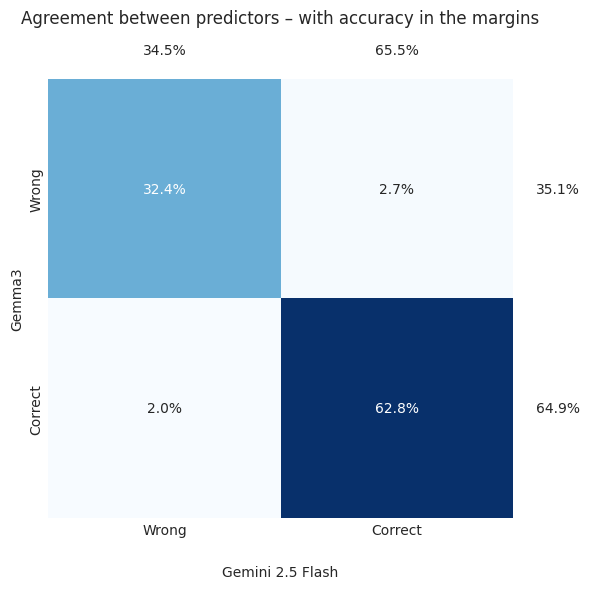

(148, 10)


In [63]:
eval_df_all = gt_df.join(
    gemini_original_eval_df[gemini_original_eval_df['contains_answer']].rename(columns={'pred_text': 'pred_text1'})[['pred_text1']],
    how='inner'
).join(
    gemini_longer_eval_df[gemini_longer_eval_df['contains_answer']].rename(columns={'pred_text': 'pred_text2'})[['pred_text2']],
    how='inner'
)

eval_df_all['text'] = eval_df_all['text'].str.lower()
eval_df_all['pred_text1'] = eval_df_all['pred_text1'].str.lower()
eval_df_all['pred_text2'] = eval_df_all['pred_text2'].str.lower()
eval_df_all[['question', 'text', 'pred_text1', 'pred_text2']]

display_eval = eval_df_all
pred_vqa_correct = (display_eval['text'] == display_eval['pred_text1']).astype(int).values
pred_gg_correct  = (display_eval['text'] == display_eval['pred_text2']).astype(int).values
labels = ['Wrong', 'Correct']

# confusion matrix (normalized over all)
cm = confusion_matrix(pred_vqa_correct, pred_gg_correct, normalize='all')

# compute marginal sums and convert to % of total
row_totals = cm.sum(axis=1)
col_totals = cm.sum(axis=0)
total = cm.sum()
row_pct = row_totals / total
col_pct = col_totals / total

fig, ax = plt.subplots(figsize=(6, 6))  
sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar=False, ax=ax)

# annotate row marginals at the right of each row
for i, p in enumerate(row_pct):
    ax.text(len(labels) + 0.1,  i + 0.5, f'{p:.1%}', 
            va='center', ha='left', fontsize=10)

# annotate column marginals just above each column
for j, p in enumerate(col_pct):
    ax.text(j + 0.5, -0.1, f'{p:.1%}', 
            ha='center', va='bottom', fontsize=10)

# move x-axis labels (and xlabel) to the top
ax.set_xlabel('Gemini 2.5 Flash', labelpad=20)
ax.set_ylabel('Gemma3')
ax.set_title('Agreement between predictors – with accuracy in the margins', pad=40)

# make xtick labels horizontal
ax.set_xticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()
print(eval_df_all.shape)


### Inspecting not answered question for longer context

In [64]:
gemini_pred_gg_df = rp.ans_extract(GEMINI_RESPONSES_LONGER_CONTEXT, "gemma3", format="gemini")


Total answers: 199
Answers following JSON template: 198
Percentage following JSON template: 99.50%
Answer with a valid alternative: 174
87.88% of the total

Invalid answers: 24


/home/lusha/star_code/src/response_processing.py:187: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(


In [65]:
gemini_unanswered = gemini_pred_gg_df[~gemini_pred_gg_df['contains_answer']]
gemini_unanswered_index = gemini_unanswered.index


## Sample

### Text inspection

In [66]:
SHOW_VIDEO = False
idx = gemini_unanswered_index[8]
idx


'Prediction_T1_183'

In [67]:
qa_viz.compact_print_qa(idx, gt_df.rename(columns={'text': 'answer'}), [gemini_pred_gg_df.rename(columns={'answer': 'pred_text'})])



┌─ Sample: Prediction_T1_183 ───────────────────────────────────────────────────────────────
│
│ Question:
│    What will the person do next?
│ Alternatives:
│    0. Open the bag.
│    1. Take the shoe.
│    2. Put down the phone/camera.
│    3. Throw the towel.
│
│ Ground Truth:
│    Put down the phone/camera.
│
│
│ Model Predictions - Prediction 1:
│    Prediction:
│         [WRONG]
│    Reasoning:
│        
│        1. **Question Interpretation:** The question asks to predict the next action of the person based on the provided Spatio-Temporal Scene Graph.
│        
│        2. **STSG Analysis:**
│            * **Frame 0:** A man is sitting at a table with a laptop. His right hand is on the laptop, and he's looking towards the right side of the frame.
│            * **Frames 1-2:** The man's right arm is extended towards an off-camera area, suggesting he's reaching for something or placing something. The laptop is still on the table.
│            * **Frame 3:** A significant change 

In [68]:
print(gemini_pred_gg_df.loc[idx]['chat_history'][0]['content'])



Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
<stsg>
Frame 0:
<scene_graph>
man ---- sitting_on ---- chair
man ---- seated_at ---- table
laptop ---- on_top_of ---- table
man ---- right_hand_on ---- laptop
man ---- left_hand_clasped_in_front_of ---- man
man ---- looking_towards ---- right_side_of_frame
chair ---- positioned_under ---- table
table ---- resting_on ---- wooden_floor
</scene_graph>

Frames 1-2:
<scene_graph>
man ---- sitting_on ---- chair
man ---- seated_at ---- table
laptop ---- on_top_of ---- table
man ---- right_arm_extended_towards ---- off-camera_area
man ---- left_hand_clasped_in_front_of ---- man
man ---- looking_towards ---- right_side_of_frame
chair ---- positioned_under ---- table
table ---- resting_on ---- wooden_floor
</scene_graph>

Frame 3:
<scene_graph>
man ---- sitting_on ---- chair
man ---- seated_at ---- table
stack_of_papers ---- being_placed_on ---- table

In [69]:
print(gemini_pred_gg_df.loc[idx]['chat_history'][1]['content'])



1. **Question Interpretation:** The question asks to predict the next action of the person based on the provided Spatio-Temporal Scene Graph.

2. **STSG Analysis:**
    * **Frame 0:** A man is sitting at a table with a laptop. His right hand is on the laptop, and he's looking towards the right side of the frame.
    * **Frames 1-2:** The man's right arm is extended towards an off-camera area, suggesting he's reaching for something or placing something. The laptop is still on the table.
    * **Frame 3:** A significant change occurs: a stack of papers is being placed on the table, and the man's right hand is over it. Crucially, the laptop has been *moved off from* the table. The man is now looking towards the table. This sequence indicates he moved the laptop and then placed papers.
    * **Frame 4:** The stack of papers is now on top of the table, and the man's right hand is on it. He is looking down at the stack of papers.
    * **Frames 5-13:** The man continues to be seated at the 

In [70]:
print(gemini_pred_gg_df.loc[idx]['chat_history'][3]['content'])



```json
{"answer": "None of the alternatives can be logically inferred from the provided Spatio-Temporal Scene Graph. The STSG describes a man interacting with a laptop and then a stack of papers, none of which relate to the objects mentioned in the alternatives (bag, shoe, phone/camera, towel). Therefore, without further information or a direct link, a choice cannot be made based purely on the provided evidence."}
```
